# correlation-ml-service — model creation, selection & evaluation

**Scope of this notebook:** train candidate risk-scoring models for the
`GraphMLScoring` strategy, compare them honestly, pick one, and register
it. This notebook is the source of truth for *which model and why*;
`train_model.py` is the lean script you'd point CI at to retrain the
already-selected model type on a schedule.

**Read before trusting any number below:** every row in the training
data is synthetic (`training/generate_synthetic_data.py`). No real
`ml-scoring-tasks` traffic was available when this was built. Treat the
metrics here as *"does the pipeline and the selection process work"*,
not *"this is production performance"*. See that file's docstring for
exactly which scenarios were encoded and why.

Feature engineering is imported directly from `src/ml_scorer.py` — not
reimplemented here — so there is no train/serve skew between this
notebook and the actual consumer/API code.


In [1]:
import sys, json
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import mlflow
import mlflow.xgboost
import xgboost as xgb
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    roc_curve, precision_recall_curve, confusion_matrix,
)

SRC_DIR = Path.cwd().parent / "src" if (Path.cwd() / "model_selection.ipynb").exists() or True else None
SRC_DIR = (Path.cwd() / ".." / "src").resolve()
sys.path.insert(0, str(SRC_DIR))

from ml_scorer import FEATURE_NAMES, MONOTONE_CONSTRAINTS, FeatureEngineer
from schemas import GraphFeatures, MLScoringTask, SignalContext

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
print("FEATURE_NAMES:", FEATURE_NAMES)
print("MONOTONE_CONSTRAINTS:", MONOTONE_CONSTRAINTS)


FEATURE_NAMES: ['fan_in_count', 'fan_in_count_missing', 'epoch_age_seconds_log1p', 'epoch_age_seconds_missing', 'fan_in_rate_log1p', 'low_and_slow_ratio', 'ti_matched_positive', 'ti_matched_known', 'signal_id_count']
MONOTONE_CONSTRAINTS: {'fan_in_count': 1, 'fan_in_count_missing': 0, 'epoch_age_seconds_log1p': 0, 'epoch_age_seconds_missing': 0, 'fan_in_rate_log1p': 1, 'low_and_slow_ratio': 1, 'ti_matched_positive': 1, 'ti_matched_known': 0, 'signal_id_count': 0}


## 1. Load data

In [2]:
DATA_PATH = Path("synthetic_ml_scoring_tasks.csv")
df = pd.read_csv(DATA_PATH, parse_dates=["event_time"])
df["drifted_period"] = df["drifted_period"].astype(bool)
# Keep timestamps tz-naive (UTC clock time) throughout the notebook -- the
# generator's timestamps are all UTC anyway, and mixing tz-aware /
# tz-naive Series (e.g. after a .values roundtrip) is a classic pandas
# footgun that breaks comparisons later.
if df["event_time"].dt.tz is not None:
    df["event_time"] = df["event_time"].dt.tz_convert("UTC").dt.tz_localize(None)
print(df.shape)
df.head()


(17500, 12)


,scenario,drifted_period,event_time,correlation_id,target_kind,target_value,fan_in_count,epoch_age_seconds,triggering_source_ip,ti_matched,signal_id_count,label
0,benign_slow_natural,False,2026-07-01 00:41:10.803044,bcd81aa8-b755-437a-a7bf-b5dc600fc237,user,user_2086,4.0,82671.53,203.0.113.202,False,2,0
1,benign_quiet,False,2026-07-01 02:35:57.230654,5de4d395-c733-4197-b443-addb813702ba,user,user_4766,3.0,1277.40,203.0.113.99,False,1,0
2,benign_slow_natural,False,2026-07-01 03:24:45.686437,f67ffb96-6357-4793-b570-dc407d359cd3,user,user_286,4.0,49038.59,203.0.113.7,False,2,0
3,benign_quiet,False,2026-07-01 04:27:12.542349,4ed1cbff-57b2-442a-bebf-d5e70bb6e2b5,user,user_4112,2.0,NaN,203.0.113.189,False,2,0
4,ambiguous_mid,False,2026-07-01 04:29:12.113522,71d16183-2d03-45ac-9203-0e3644011f11,user,user_973,NaN,16678.40,203.0.113.102,False,2,0


In [3]:
print(df["scenario"].value_counts())
print()
print("Overall positive rate:", df["label"].mean().round(3))
print("Drifted-period share of rows:", df["drifted_period"].mean().round(3))


scenario
benign_slow_natural    2500
benign_quiet           2500
ambiguous_mid          2500
loud_burst             2500
ti_confirmed           2500
benign_shared_nat      2500
low_and_slow           2500
Name: count, dtype: int64

Overall positive rate: 0.468
Drifted-period share of rows: 0.2


## 2. Exploratory visualization

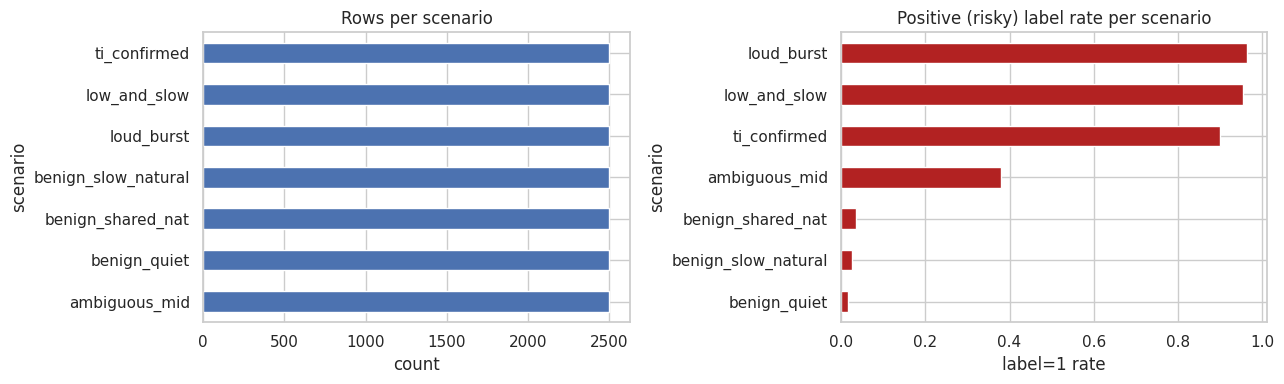

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df["scenario"].value_counts().sort_index().plot.barh(ax=axes[0])
axes[0].set_title("Rows per scenario")
axes[0].set_xlabel("count")

pos_by_scenario = df.groupby("scenario")["label"].mean().sort_values()
pos_by_scenario.plot.barh(ax=axes[1], color="firebrick")
axes[1].set_title("Positive (risky) label rate per scenario")
axes[1].set_xlabel("label=1 rate")

plt.tight_layout()
plt.show()


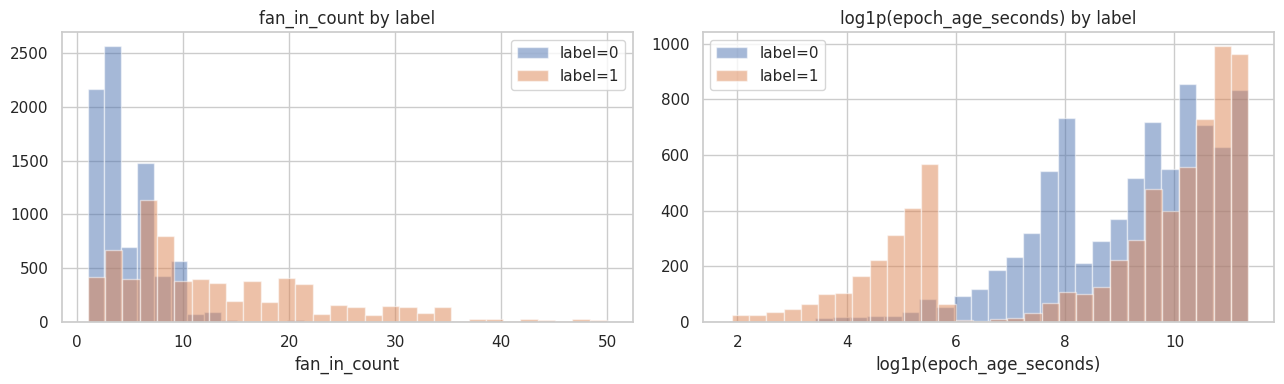

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for label, group in df.groupby("label"):
    axes[0].hist(group["fan_in_count"].dropna(), bins=30, alpha=0.5, label=f"label={label}")
axes[0].set_title("fan_in_count by label")
axes[0].set_xlabel("fan_in_count")
axes[0].legend()

for label, group in df.groupby("label"):
    axes[1].hist(np.log1p(group["epoch_age_seconds"].dropna()), bins=30, alpha=0.5, label=f"label={label}")
axes[1].set_title("log1p(epoch_age_seconds) by label")
axes[1].set_xlabel("log1p(epoch_age_seconds)")
axes[1].legend()

plt.tight_layout()
plt.show()


### Time visualization

This is the one plot in the notebook that exists purely to validate the
*monitoring* story, not the model: `generate_synthetic_data.py` deliberately
shifts two distributions in the final 20% of the time window (bigger
`loud_burst` bursts, bigger `benign_shared_nat` fan-in). If this plot
doesn't show a visible shift at the drift boundary, the drift-injection
code has a bug.


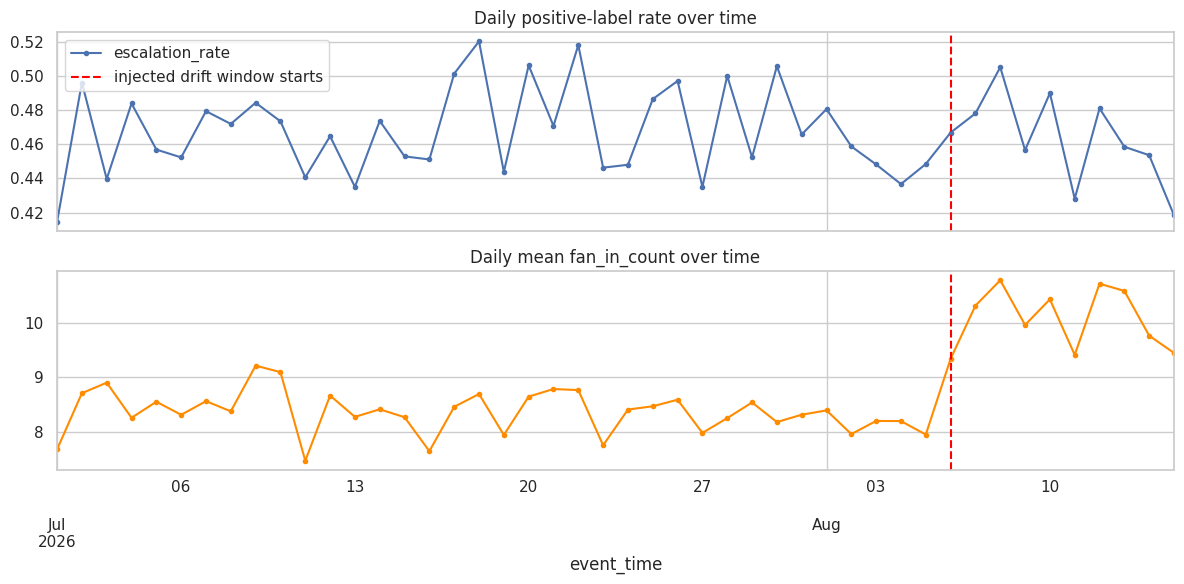

In [6]:
daily = (
    df.set_index("event_time")
      .resample("1D")
      .agg(escalation_rate=("label", "mean"), n=("label", "size"), mean_fan_in=("fan_in_count", "mean"))
)

drift_start = df.loc[df["drifted_period"], "event_time"].min()

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
daily["escalation_rate"].plot(ax=axes[0], marker="o", ms=3)
axes[0].axvline(drift_start, color="red", linestyle="--", label="injected drift window starts")
axes[0].set_title("Daily positive-label rate over time")
axes[0].legend()

daily["mean_fan_in"].plot(ax=axes[1], marker="o", ms=3, color="darkorange")
axes[1].axvline(drift_start, color="red", linestyle="--")
axes[1].set_title("Daily mean fan_in_count over time")

plt.tight_layout()
plt.show()


## 3. Feature engineering (imported from `src/`, not reimplemented)

Every row is converted through the exact `MLScoringTask` -> `FeatureEngineer`
path the Kafka consumer and API use. This is the guardrail against
train/serve skew.


In [7]:
def row_to_task(row) -> MLScoringTask:
    def opt(v):
        return None if pd.isna(v) else v
    ti = row["ti_matched"]
    ti_val = None if pd.isna(ti) else bool(ti)
    return MLScoringTask(
        correlation_id=row["correlation_id"],
        target_kind=row["target_kind"],
        target_value=row["target_value"],
        graph_features=GraphFeatures(
            fan_in_count=opt(row["fan_in_count"]) and int(row["fan_in_count"]) if not pd.isna(row["fan_in_count"]) else None,
            epoch_age_seconds=opt(row["epoch_age_seconds"]),
        ),
        signal_context=SignalContext(
            triggering_source_ip=row["triggering_source_ip"],
            ti_matched=ti_val,
            signal_ids=[f"sig-{i}" for i in range(int(row["signal_id_count"]))],
        ),
    )

feat_rows = []
for _, row in df.iterrows():
    task = row_to_task(row)
    feat_rows.append(FeatureEngineer.transform(task).vector[0])

X = np.vstack(feat_rows)
y = df["label"].to_numpy(dtype=float)
feat_df = pd.DataFrame(X, columns=FEATURE_NAMES)
feat_df["label"] = y
feat_df["event_time"] = df["event_time"].values
feat_df["scenario"] = df["scenario"].values
feat_df.head()


,fan_in_count,fan_in_count_missing,epoch_age_seconds_log1p,epoch_age_seconds_missing,fan_in_rate_log1p,low_and_slow_ratio,ti_matched_positive,ti_matched_known,signal_id_count,label,event_time,scenario
0,4.0,0.0,11.322643,0.0,0.000048,0.353274,0.0,1.0,2.0,0.0,2026-07-01 00:41:10.803044,benign_slow_natural
1,3.0,0.0,7.153365,0.0,0.002346,0.419383,0.0,1.0,1.0,0.0,2026-07-01 02:35:57.230654,benign_quiet
2,4.0,0.0,10.800383,0.0,0.000082,0.370357,0.0,1.0,2.0,0.0,2026-07-01 03:24:45.686437,benign_slow_natural
3,2.0,0.0,0.693147,1.0,1.098612,2.885390,0.0,1.0,2.0,0.0,2026-07-01 04:27:12.542349,benign_quiet
4,0.0,1.0,9.721930,0.0,0.000000,0.000000,0.0,1.0,2.0,0.0,2026-07-01 04:29:12.113522,ambiguous_mid


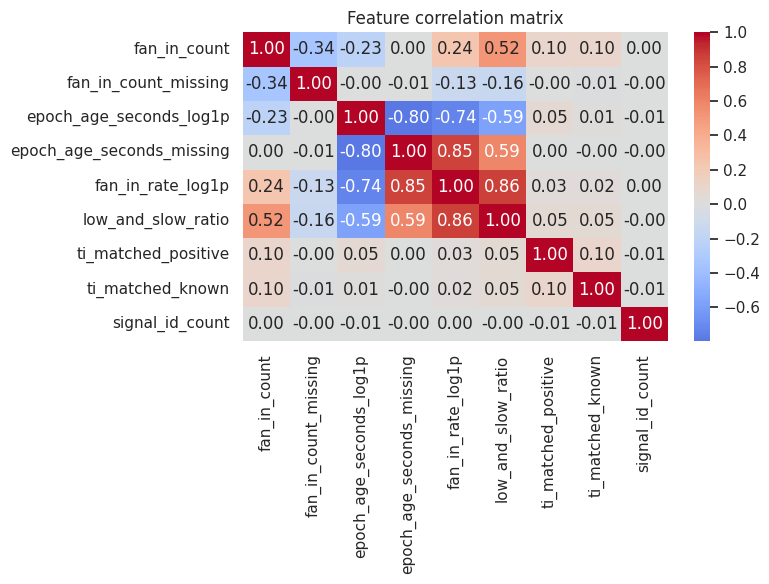

In [8]:
plt.figure(figsize=(8, 6))
sns.heatmap(feat_df[FEATURE_NAMES].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.show()


## 4. Time-aware train / validation / test split

Random splits leak the future into training for time-series-shaped risk
data. Splitting on `event_time` instead means the test set includes the
injected drift window — a more honest estimate of "how does this model
do on data shaped differently from most of what it trained on", which is
exactly the situation this service will actually be in a month after
deployment.


In [9]:
feat_df_sorted = feat_df.sort_values("event_time").reset_index(drop=True)
n = len(feat_df_sorted)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

train_df = feat_df_sorted.iloc[:train_end]
val_df = feat_df_sorted.iloc[train_end:val_end]
test_df = feat_df_sorted.iloc[val_end:]

X_train, y_train = train_df[FEATURE_NAMES].values, train_df["label"].values
X_val, y_val = val_df[FEATURE_NAMES].values, val_df["label"].values
X_test, y_test = test_df[FEATURE_NAMES].values, test_df["label"].values

drift_start_ts = pd.Timestamp(df.loc[df["drifted_period"], "event_time"].min())
test_includes_drift = pd.Timestamp(test_df["event_time"].max()) >= drift_start_ts

print(f"train={len(train_df)}  val={len(val_df)}  test={len(test_df)}")
print(f"train window: {train_df.event_time.min()} .. {train_df.event_time.max()}")
print(f"test  window: {test_df.event_time.min()} .. {test_df.event_time.max()}")
print(f"test set includes the injected drift period: {test_includes_drift}")


train=12250  val=2625  test=2625
train window: 2026-07-01 00:41:10.803044 .. 2026-08-01 21:51:41.764827
test  window: 2026-08-08 16:31:07.146917 .. 2026-08-15 22:47:20.667821
test set includes the injected drift period: True


## 5. Candidate models

Three candidates, all on the spec's explicit allow-list (interpretable,
no deep learning, no unsupervised anomaly detection as primary model):

- **XGBoost** with monotonic constraints on `fan_in_count`, `fan_in_rate_log1p`,
  `low_and_slow_ratio`, `ti_matched_positive`
- **LightGBM** with the same monotonic constraints, as a second tree-based
  opinion (different split-finding algorithm, useful cross-check)
- **Logistic Regression** as an interpretable linear baseline — if this
  gets close to the tree models, that's a strong argument *for* shipping
  the simpler model instead

Each run is logged to MLflow (local file store at `../mlruns`) as a
nested run under one parent `model_selection` run.


In [10]:
# MLflow 3.x puts the plain filesystem store ('file:./mlruns') in maintenance
# mode with no Model Registry support -- use a SQLite-backed store instead,
# which supports registry model-version/stage transitions used in section 10.
mlflow.set_tracking_uri("sqlite:///" + str((Path.cwd() / ".." / "mlflow.db").resolve()))
mlflow.set_experiment("correlation-ml-service")

monotone_str = "(" + ",".join(str(MONOTONE_CONSTRAINTS[f]) for f in FEATURE_NAMES) + ")"
monotone_list = [MONOTONE_CONSTRAINTS[f] for f in FEATURE_NAMES]

results = {}
models = {}


2026/08/14 07:48:13 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/08/14 07:48:13 INFO mlflow.store.db.utils: Updating database tables


2026/08/14 07:48:15 INFO mlflow.tracking.fluent: Experiment with name 'correlation-ml-service' does not exist. Creating a new experiment.


In [11]:
# --- XGBoost ---
with mlflow.start_run(run_name="xgboost_monotonic") as run:
    dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=FEATURE_NAMES)
    dval = xgb.DMatrix(X_val, label=y_val, feature_names=FEATURE_NAMES)
    dtest = xgb.DMatrix(X_test, label=y_test, feature_names=FEATURE_NAMES)

    params = dict(objective="binary:logistic", eval_metric="aucpr", max_depth=4, eta=0.1,
                  subsample=0.8, colsample_bytree=0.8, monotone_constraints=monotone_str, seed=13)
    mlflow.log_params(params)

    booster = xgb.train(params, dtrain, num_boost_round=300,
                         evals=[(dtrain, "train"), (dval, "val")],
                         early_stopping_rounds=20, verbose_eval=False)

    preds = booster.predict(dtest, iteration_range=(0, booster.best_iteration + 1))
    auc = roc_auc_score(y_test, preds); ap = average_precision_score(y_test, preds)
    brier = brier_score_loss(y_test, preds)
    mlflow.log_metrics({"test_roc_auc": auc, "test_avg_precision": ap, "test_brier": brier,
                         "best_iteration": booster.best_iteration})

    results["xgboost"] = dict(preds=preds, auc=auc, ap=ap, brier=brier, run_id=run.info.run_id)
    models["xgboost"] = booster
    print(f"xgboost   AUC={auc:.4f}  AP={ap:.4f}  Brier={brier:.4f}  best_iter={booster.best_iteration}")


xgboost   AUC=0.8933  AP=0.8716  Brier=0.1375  best_iter=82


In [12]:
# --- LightGBM ---
with mlflow.start_run(run_name="lightgbm_monotonic") as run:
    train_set = lgb.Dataset(X_train, label=y_train, feature_name=FEATURE_NAMES)
    val_set = lgb.Dataset(X_val, label=y_val, feature_name=FEATURE_NAMES, reference=train_set)

    params = dict(objective="binary", metric="average_precision", max_depth=4, learning_rate=0.1,
                  num_leaves=15, feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=1,
                  monotone_constraints=monotone_list, verbose=-1, seed=13)
    mlflow.log_params(params)

    gbm = lgb.train(params, train_set, num_boost_round=300, valid_sets=[val_set],
                     callbacks=[lgb.early_stopping(20, verbose=False)])

    preds = gbm.predict(X_test, num_iteration=gbm.best_iteration)
    auc = roc_auc_score(y_test, preds); ap = average_precision_score(y_test, preds)
    brier = brier_score_loss(y_test, preds)
    mlflow.log_metrics({"test_roc_auc": auc, "test_avg_precision": ap, "test_brier": brier,
                         "best_iteration": gbm.best_iteration})

    results["lightgbm"] = dict(preds=preds, auc=auc, ap=ap, brier=brier, run_id=run.info.run_id)
    models["lightgbm"] = gbm
    print(f"lightgbm  AUC={auc:.4f}  AP={ap:.4f}  Brier={brier:.4f}  best_iter={gbm.best_iteration}")


lightgbm  AUC=0.8923  AP=0.8694  Brier=0.1374  best_iter=77


In [13]:
# --- Logistic Regression (interpretable linear baseline) ---
with mlflow.start_run(run_name="logistic_regression_baseline") as run:
    scaler = StandardScaler().fit(X_train)
    Xtr_s, Xte_s = scaler.transform(X_train), scaler.transform(X_test)

    clf = LogisticRegression(max_iter=1000, C=1.0)
    clf.fit(Xtr_s, y_train)
    mlflow.log_params({"C": 1.0, "max_iter": 1000})

    preds = clf.predict_proba(Xte_s)[:, 1]
    auc = roc_auc_score(y_test, preds); ap = average_precision_score(y_test, preds)
    brier = brier_score_loss(y_test, preds)
    mlflow.log_metrics({"test_roc_auc": auc, "test_avg_precision": ap, "test_brier": brier})

    results["logistic_regression"] = dict(preds=preds, auc=auc, ap=ap, brier=brier, run_id=run.info.run_id)
    models["logistic_regression"] = (clf, scaler)
    print(f"logreg    AUC={auc:.4f}  AP={ap:.4f}  Brier={brier:.4f}")

    coef_df = pd.DataFrame({"feature": FEATURE_NAMES, "coefficient": clf.coef_[0]}).sort_values("coefficient")
    print(coef_df.to_string(index=False))


logreg    AUC=0.8918  AP=0.8798  Brier=0.1317
                  feature  coefficient
  epoch_age_seconds_log1p    -0.339251
epoch_age_seconds_missing    -0.278013
       low_and_slow_ratio    -0.257257
          signal_id_count    -0.015166
        fan_in_rate_log1p     0.145560
         ti_matched_known     0.331260
     fan_in_count_missing     0.715801
      ti_matched_positive     1.327127
             fan_in_count     2.320993


## 6. Compare candidates: ROC, PR, calibration

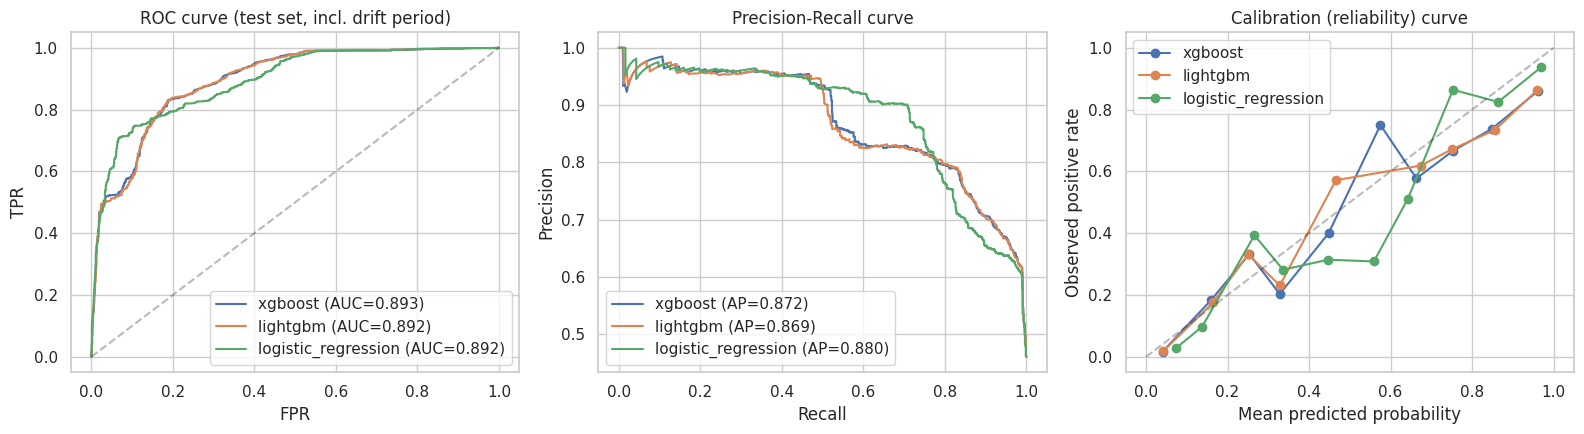

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r["preds"])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={r['auc']:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0].set_title("ROC curve (test set, incl. drift period)")
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR"); axes[0].legend()

for name, r in results.items():
    prec, rec, _ = precision_recall_curve(y_test, r["preds"])
    axes[1].plot(rec, prec, label=f"{name} (AP={r['ap']:.3f})")
axes[1].set_title("Precision-Recall curve")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision"); axes[1].legend()

for name, r in results.items():
    prob_true, prob_pred = [], []
    bins = np.linspace(0, 1, 11)
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (r["preds"] >= lo) & (r["preds"] < hi)
        if mask.sum() > 5:
            prob_true.append(y_test[mask].mean())
            prob_pred.append(r["preds"][mask].mean())
    axes[2].plot(prob_pred, prob_true, marker="o", label=name)
axes[2].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[2].set_title("Calibration (reliability) curve")
axes[2].set_xlabel("Mean predicted probability"); axes[2].set_ylabel("Observed positive rate")
axes[2].legend()

plt.tight_layout()
plt.show()


## 7. The two checks that matter more than the headline metrics

AUC/AP describe average performance. This service's whole reason for
existing is to handle two specific edge cases correctly. Both are
evaluated per-candidate, not just for the eventual winner.


In [15]:
def make_task(fan_in, age, ti, sid="probe"):
    return MLScoringTask(
        correlation_id="00000000-0000-0000-0000-000000000001",
        target_kind="user", target_value=sid,
        graph_features=GraphFeatures(fan_in_count=fan_in, epoch_age_seconds=age),
        signal_context=SignalContext(triggering_source_ip="203.0.113.9", ti_matched=ti, signal_ids=["s1"]),
    )

def featurize(task):
    return FeatureEngineer.transform(task).vector

def predict_one(name, vec):
    if name == "logistic_regression":
        clf, scaler = models[name]
        return float(clf.predict_proba(scaler.transform(vec))[0, 1])
    if name == "lightgbm":
        return float(models[name].predict(vec, num_iteration=models[name].best_iteration)[0])
    dm = xgb.DMatrix(vec, feature_names=FEATURE_NAMES)
    return float(models[name].predict(dm, iteration_range=(0, models[name].best_iteration + 1))[0])

# Check A: low-and-slow trap -- same rate, very different absolute count/age
trap_attack = featurize(make_task(fan_in=18, age=18*3600, ti=None))
trap_benign = featurize(make_task(fan_in=2, age=2*3600, ti=None))

# Check B: benign_shared_nat false-positive risk -- moderate fan-in from one office
nat_benign = featurize(make_task(fan_in=8, age=3*3600, ti=None))

print(f"{'model':22s} {'trap_attack':>12s} {'trap_benign':>12s} {'trap_pass':>10s} {'shared_nat_p':>13s}")
for name in models:
    p_attack = predict_one(name, trap_attack)
    p_benign = predict_one(name, trap_benign)
    p_nat = predict_one(name, nat_benign)
    trap_pass = p_attack > p_benign
    print(f"{name:22s} {p_attack:12.4f} {p_benign:12.4f} {str(trap_pass):>10s} {p_nat:13.4f}")


model                   trap_attack  trap_benign  trap_pass  shared_nat_p
xgboost                      0.7905       0.0112       True        0.0962
lightgbm                     0.7425       0.0076       True        0.0956
logistic_regression          0.5653       0.0125       True        0.0695


## 8. Feature importance and SHAP

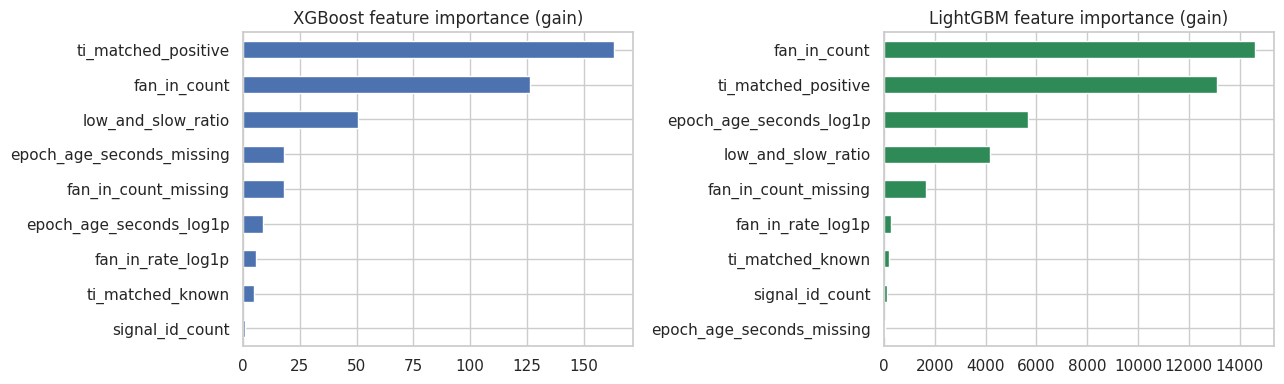

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

xgb_imp = models["xgboost"].get_score(importance_type="gain")
pd.Series(xgb_imp).sort_values().plot.barh(ax=axes[0])
axes[0].set_title("XGBoost feature importance (gain)")

lgb_imp = pd.Series(models["lightgbm"].feature_importance(importance_type="gain"), index=FEATURE_NAMES)
lgb_imp.sort_values().plot.barh(ax=axes[1], color="seagreen")
axes[1].set_title("LightGBM feature importance (gain)")

plt.tight_layout()
plt.show()


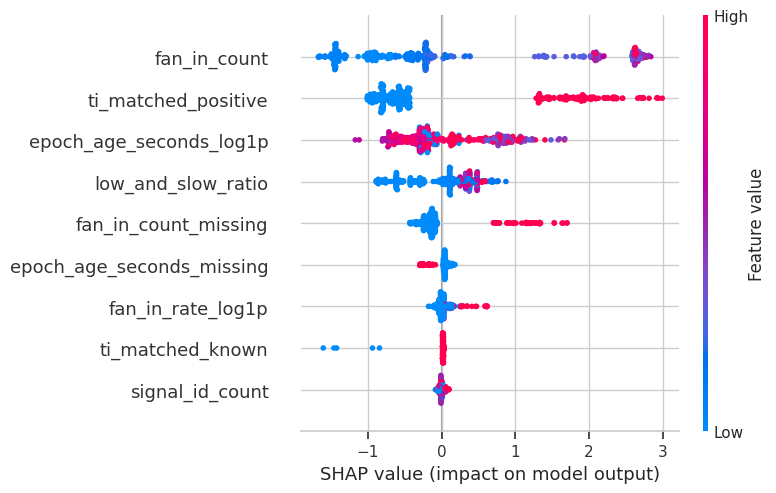

In [17]:
# SHAP summary for the tree model most likely to be selected (XGBoost).
# Subsampled for speed -- this is exploratory, not a production explainability pipeline.
explainer = shap.TreeExplainer(models["xgboost"])
sample_idx = np.random.RandomState(13).choice(len(X_test), size=min(400, len(X_test)), replace=False)
shap_values = explainer.shap_values(X_test[sample_idx])

shap.summary_plot(shap_values, X_test[sample_idx], feature_names=FEATURE_NAMES, show=False)
plt.tight_layout()
plt.show()


### Monotonicity compliance check

XGBoost and LightGBM had `monotone_constraints` enforced *during training*,
so they're compliant by construction. Logistic regression was not
constrained — check whether its fitted coefficient signs happen to agree
with the same causal story anyway. Multicollinearity between
`low_and_slow_ratio`, `fan_in_count`, and `epoch_age_seconds_log1p` (they're
all derived from the same two raw inputs) means an unconstrained linear
model is free to push the "risk story" onto whichever correlated feature
fits the training data best, even if that gives an individual feature the
wrong sign.


In [18]:
logreg_coefs = dict(zip(FEATURE_NAMES, models["logistic_regression"][0].coef_[0]))
print(f"{'feature':28s} {'constraint':>10s} {'coefficient':>12s} {'compliant':>10s}")
violations = []
for feat in FEATURE_NAMES:
    constraint = MONOTONE_CONSTRAINTS[feat]
    coef = logreg_coefs[feat]
    if constraint == 0:
        compliant = True
    else:
        compliant = (coef * constraint) > 0
    if not compliant:
        violations.append(feat)
    print(f"{feat:28s} {constraint:>10d} {coef:>12.4f} {str(compliant):>10s}")

print()
if violations:
    print(f"*** logistic_regression VIOLATES the intended monotonic story on: {violations} ***")
else:
    print("logistic_regression's coefficients agree with all declared constraints.")


feature                      constraint  coefficient  compliant
fan_in_count                          1       2.3210       True
fan_in_count_missing                  0       0.7158       True
epoch_age_seconds_log1p               0      -0.3393       True
epoch_age_seconds_missing             0      -0.2780       True
fan_in_rate_log1p                     1       0.1456       True
low_and_slow_ratio                    1      -0.2573      False
ti_matched_positive                   1       1.3271       True
ti_matched_known                      0       0.3313       True
signal_id_count                       0      -0.0152       True

*** logistic_regression VIOLATES the intended monotonic story on: ['low_and_slow_ratio'] ***


## 9. Model selection

Decision, in order of what actually matters for this service:

1. **Low-and-slow trap (Check A)** — non-negotiable. Any candidate that
   fails it is disqualified regardless of AUC, because it means the
   model learned "rate" instead of "sustained volume", which is the
   opposite of what the spec asks for.
2. **Monotonicity compliance** — also non-negotiable for the specific
   feature the spec calls out (`low_and_slow_ratio`). A model that gets
   the *sign* wrong on that feature can look fine on average metrics
   while still being untrustworthy on exactly the pattern this service
   exists to catch, once real traffic doesn't share the training data's
   correlation structure.
3. **benign_shared_nat false-positive rate (Check B)** — the realistic
   failure mode most likely to page someone at 3am. Lower is better.
4. **Test-set AUC / AP / Brier**, computed on a split that *includes* the
   injected drift period — the tie-breaker among whatever survives 1-3,
   not the primary criterion.

Run the cell below after the ones above; it computes the actual decision
from what this run produced, rather than asserting a fixed winner.


In [19]:
summary = pd.DataFrame({
    name: {"test_auc": r["auc"], "test_ap": r["ap"], "test_brier": r["brier"]}
    for name, r in results.items()
}).T.round(4)
summary["shared_nat_p"] = {
    name: predict_one(name, nat_benign) for name in models
}
print(summary)
print()

# Disqualify on hard constraints first (trap check + monotonicity), THEN
# rank survivors by AP. This is what actually decides the winner below --
# not a fixed string.
disqualified = set()
if violations:  # from the monotonicity check above -- currently only checked for logreg
    disqualified.add("logistic_regression")

survivors = [m for m in results if m not in disqualified]
ranked_survivors = summary.loc[survivors].sort_values("test_ap", ascending=False)
winner = ranked_survivors.index[0]

print(f"Disqualified (monotonicity violation on a spec-critical feature): {sorted(disqualified) or 'none'}")
print(f"Surviving candidates ranked by AP:\n{ranked_survivors}")
print(f"\nSelected: {winner}")
print(f"(Highest raw AP without the monotonicity filter would have been "
      f"'{summary['test_ap'].idxmax()}' -- overridden because it fails check 2 above.)")


                     test_auc  test_ap  test_brier  shared_nat_p
xgboost                0.8933   0.8716      0.1375      0.096230
lightgbm               0.8923   0.8694      0.1374      0.095558
logistic_regression    0.8918   0.8798      0.1317      0.069495

Disqualified (monotonicity violation on a spec-critical feature): ['logistic_regression']
Surviving candidates ranked by AP:
          test_auc  test_ap  test_brier  shared_nat_p
xgboost     0.8933   0.8716      0.1375      0.096230
lightgbm    0.8923   0.8694      0.1374      0.095558

Selected: xgboost
(Highest raw AP without the monotonicity filter would have been 'logistic_regression' -- overridden because it fails check 2 above.)


## 10. Register the winner

Saves the model both ways the serving code understands (see `CML_MODEL_SOURCE`
in `src/config.py`):

- a local `artifacts/model_latest.joblib` (fast path, no MLflow dependency
  at serving time)
- an MLflow-registered model version (`models:/correlation-ml-service-risk-model/…`),
  transitioned to `Staging` — promote to `Production` manually once it's been
  validated against real traffic.

Uses `winner` from the cell above — nothing hardcoded here. If the data
changes (real traffic instead of synthetic) and a different candidate
survives disqualification with a better AP, this cell follows it
automatically. If `winner` isn't XGBoost or LightGBM, the save step below
needs a different branch (this notebook doesn't have an MLflow-native
logistic regression save path wired up, since it wasn't needed this run).


In [20]:
import joblib

assert winner in ("xgboost", "lightgbm"), (
    f"winner={winner!r} has no save path wired up in this cell -- add one "
    f"before running (see the markdown above)."
)

MODEL_VERSION = f"gml-svc-0.2.0-synthetic-{datetime.now(timezone.utc):%Y%m%d}-{winner}"
ARTIFACT_DIR = Path.cwd().parent / "artifacts"
ARTIFACT_DIR.mkdir(exist_ok=True)

chosen_booster = models[winner]

artifact_path = ARTIFACT_DIR / "model_latest.joblib"
joblib.dump({"booster": chosen_booster, "model_version": MODEL_VERSION, "feature_names": FEATURE_NAMES}, artifact_path)
print("Saved:", artifact_path)

log_fn = mlflow.xgboost.log_model if winner == "xgboost" else mlflow.lightgbm.log_model
import mlflow.lightgbm  # noqa: E402

with mlflow.start_run(run_name="register_winner") as run:
    mlflow.log_param("chosen_model", winner)
    mlflow.log_metrics({f"chosen_{k}": v for k, v in summary.loc[winner].items()})
    model_info = log_fn(chosen_booster, name="model", registered_model_name="correlation-ml-service-risk-model")
    print("Registered model URI:", model_info.model_uri)

client = mlflow.MlflowClient()
versions = client.search_model_versions("name='correlation-ml-service-risk-model'")
latest = max(versions, key=lambda v: int(v.version))
client.transition_model_version_stage(
    name="correlation-ml-service-risk-model", version=latest.version, stage="Staging",
)
print(f"Model version {latest.version} ({winner}) moved to Staging.")


Saved: /home/claude/correlation-ml-service/services/correlation-ml-service/artifacts/model_latest.joblib


Registered model URI: models:/m-975d285928364795ac2f6b6c35124fd5
Model version 1 (xgboost) moved to Staging.


Successfully registered model 'correlation-ml-service-risk-model'.
Created version '1' of model 'correlation-ml-service-risk-model'.
/tmp/ipykernel_624/3122800927.py:30: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(


## Next steps (not in this notebook)

- Swap `synthetic_ml_scoring_tasks.csv` for real historical GraphPivotStrategy
  output as soon as it exists, and rerun sections 4-10.
- `training/evaluate_model.py` runs the Check A / Check B regression tests
  as an automated CI gate (fails the build, doesn't just print a warning).
- `docs/02-model-creation-and-selection.md` narrates this notebook for
  someone who won't run it.
